Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**  
Course: **Computer Engineering - Artificial Intelligence / Machine Learning**

**TASK 1: Regression**

**Scenario:**<p> 
A consumer-electronics company is developing an on-device thermal-management feature for its flagship
smartphone. Engineers want to anticipate how hot the lithium-ion battery will get during fast-charging
sessions so the firmware can throttle the input current preemptively, avoiding thermal damage and
extending overall battery lifespan. Sensor logs were collected from 5,000 charging cycles under varied
currents, ambient conditions, and battery ages. The team wants to build a model that estimates the final
battery temperature in degrees Celsius given the charging parameters and the device's current state.
</p>


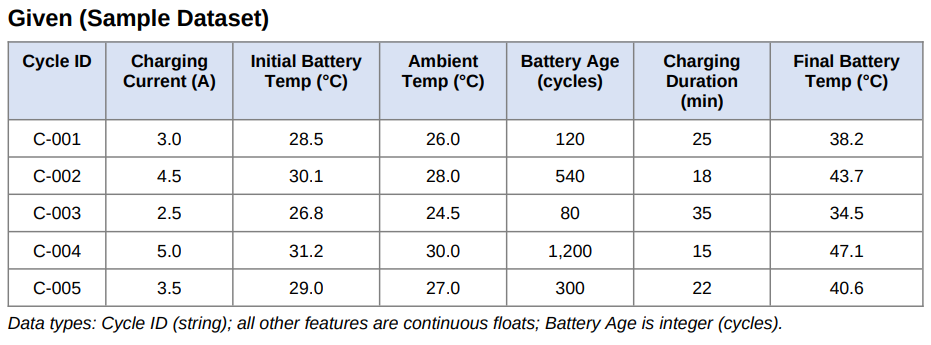

---

##### **Step 1: Import Libraries**

In [19]:
import tensorflow as tf 
import pandas as pd 
import numpy as np 
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


print(f'tensorflow: {tf.__version__}\n', 
      f'pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}')

tensorflow: 2.21.0
 pandas: 3.0.2
 numpy: 2.4.2
 sklearn: 1.8.0


##### **Step 2: Prep Dataset**


Format the given sample dataset into a pandas dataframe. 

In [20]:
data = {
    "CycleID": ["C-001", "C-002", "C-003", "C-004", "C-005"], 
    "ChargCurrent": [3.0, 4.5, 2.5, 5.0, 3.5],
    "InitBattTemp": [28.5, 30.1, 26.8, 31.2, 29.0],
    "AmbTemp": [26.0, 28.0, 24.5, 30.0, 27.0], 
    "BattAge": [120, 540, 80, 1200, 300],
    "ChargDur": [25, 18, 35, 15, 22],
    "FinalBattTemp": [38.2, 43.7, 34.5, 47.1, 40.6]
}

df_actual = pd.DataFrame(data)

df_actual = df_actual.drop(columns=["CycleID"])

print(df_actual)

   ChargCurrent  InitBattTemp  AmbTemp  BattAge  ChargDur  FinalBattTemp
0           3.0          28.5     26.0      120        25           38.2
1           4.5          30.1     28.0      540        18           43.7
2           2.5          26.8     24.5       80        35           34.5
3           5.0          31.2     30.0     1200        15           47.1
4           3.5          29.0     27.0      300        22           40.6


Assign inputs(features) and outputs(labels).

In [21]:
x_actual = df_actual.drop(columns=["FinalBattTemp"])
y_actual = df_actual["FinalBattTemp"]

print(f'{x_actual}', f'\n\n{y_actual}')

   ChargCurrent  InitBattTemp  AmbTemp  BattAge  ChargDur
0           3.0          28.5     26.0      120        25
1           4.5          30.1     28.0      540        18
2           2.5          26.8     24.5       80        35
3           5.0          31.2     30.0     1200        15
4           3.5          29.0     27.0      300        22 

0    38.2
1    43.7
2    34.5
3    47.1
4    40.6
Name: FinalBattTemp, dtype: float64


Generate a synthetic dataset containing 5000 samples with the min/max values based on the given sample dataset.

In [22]:
n_samples = 5000

x_synth = pd.DataFrame({
    "ChargCurrent": np.random.uniform(1, 5.0, n_samples),
    "InitBattTemp": np.random.uniform(20, 38, n_samples),
    "AmbTemp": np.random.uniform(22, 40, n_samples),
    "BattAge": np.random.randint(5, 1600, n_samples),
    "ChargDur": np.random.uniform(10, 45, n_samples),
})

tempModel = sklearn.linear_model.LinearRegression().fit(x_actual, y_actual)

y_synth_clean = tempModel.predict(x_synth)
noise = np.random.normal(0, 0.5, n_samples)
y_synth = y_synth_clean + noise

Normalize features using `StandardScaler()`

In [23]:
scaler = StandardScaler()

x_synth_scaled = scaler.fit_transform(x_synth)
x_actual_scaled = scaler.transform(x_actual)

x_synth_scaled.shape, x_actual_scaled.shape

((5000, 5), (5, 5))

##### **Step 3: Build the Model**

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(8),
    tf.keras.layers.Dense(1) 
])

model.compile(loss = 'mse',
              optimizer = 'adam',
              metrics = ['mse'])

# save model history to plot later
history = model.fit(x_synth_scaled, y_synth, 
                    epochs = 10,
                    validation_split = 0.2
                    )

Epoch 1/10


I0000 00:00:1778777281.849580   56790 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17827__.8


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1765.5834 - mse: 1765.5834 - val_loss: 1673.8636 - val_mse: 1673.8636
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1414.3093 - mse: 1414.3093 - val_loss: 1046.5267 - val_mse: 1046.5267
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 586.1728 - mse: 586.1728 - val_loss: 181.2121 - val_mse: 181.2121
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 48.5153 - mse: 48.5153 - val_loss: 1.5802 - val_mse: 1.5802
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4616 - mse: 0.4616 - val_loss: 0.2265 - val_mse: 0.2265
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2675 - mse: 0.2675 - val_loss: 0.2274 - val_mse: 0.2274
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2679 - mse: 0.2679 - val_loss: 0.2266 - val_mse: 0.2266
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2676 - mse: 0.2676 - val_loss: 0.2277 - val_mse: 0.2277
Epoch 9/10
125/125 ━━━━━━━━━━━━━

Evaluate the model

In [25]:
test_loss, test_mse = model.evaluate(x_actual_scaled, np.array(y_actual))
test_loss, test_mse

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.0013 - mse: 0.0013


(0.001254790578968823, 0.001254790578968823)

##### **Step 4: Display Results**

Loss and MAE History Plot

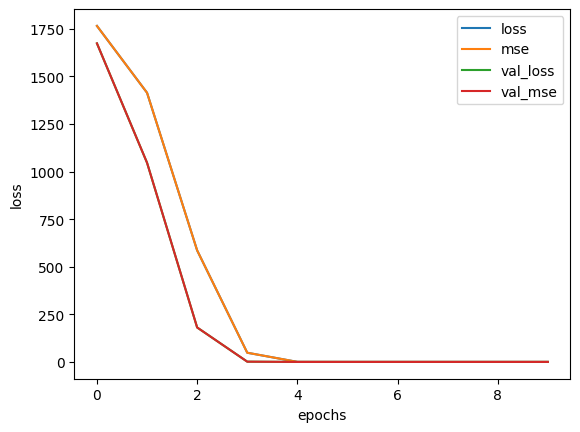

In [26]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel("epochs")
mpl.pyplot.ylabel("loss");

<p> Compare Prediction to Sample </p>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


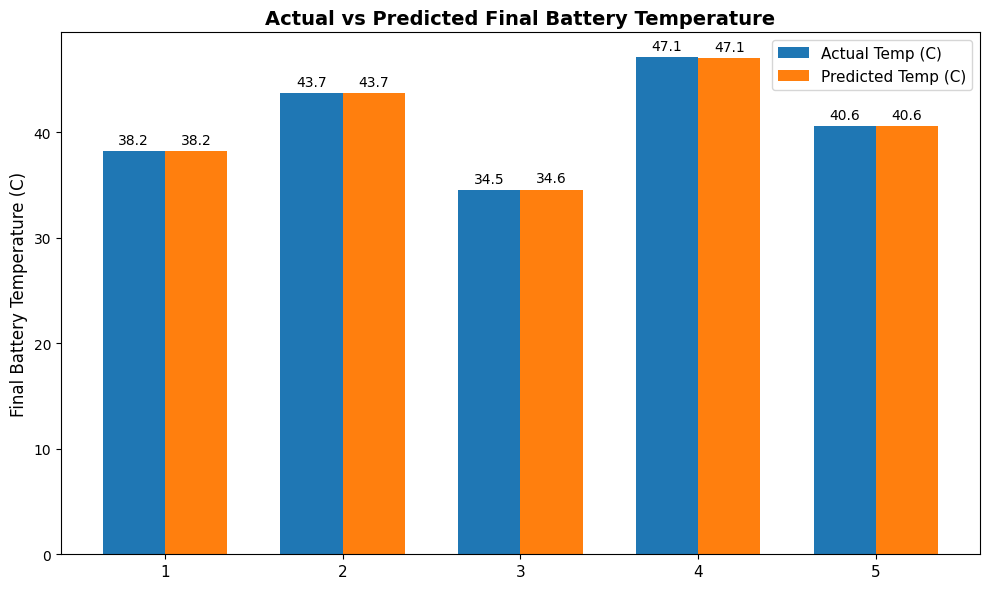

In [29]:
predictions = model.predict(x_actual_scaled).flatten()

labels = [f"{i+1}" for i in range(len(np.array(y_actual)))]
x = np.arange(len(labels))  
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_actual = ax.bar(x - width/2, (np.array(y_actual)), width, label='Actual Temp (C)', color='#1f77b4')
bars_pred = ax.bar(x + width/2, predictions, width, label='Predicted Temp (C)', color='#ff7f0e')

ax.set_ylabel('Final Battery Temperature (C)', fontsize=12)
ax.set_title('Actual vs Predicted Final Battery Temperature', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

ax.bar_label(bars_actual, padding=3, fmt='%.1f')
ax.bar_label(bars_pred, padding=3, fmt='%.1f')

fig.tight_layout()

plt.show()